In [3]:
Sys.setlocale("LC_ALL", "en_US.UTF-8")
Sys.getlocale()

[1] "en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/C"

[1] "en_US.UTF-8/en_US.UTF-8/en_US.UTF-8/C/en_US.UTF-8/C"

$beta
              5.1470     4.8001    4.4766    4.1749    3.8935    3.6311
(Intercept) 20.09062 21.8289027 23.450026 24.961892 26.371862 27.686806
cyl          0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
disp         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
hp           0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
drat         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
wt           0.00000 -0.5402992 -1.044184 -1.514109 -1.952362 -2.361079
qsec         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
vs           0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
am           0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
gear         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
carb         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
               3.3864   3.1581    2.9453    2.7468    2.5617    2.3890
(Intercept) 28.913126 30.05680 31.123388 32.118095 33.04576

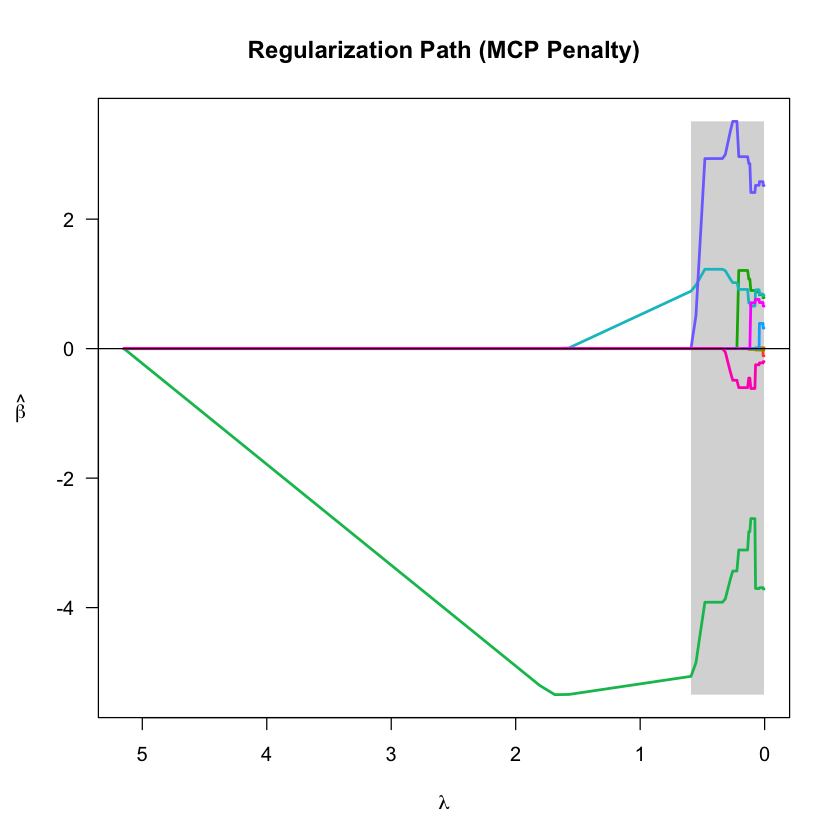

Optimal lambda (lambda.min): 0.5146981 
Lambda at 1 SE from min (lambda.1se): 

Coefficients at lambda.min:
              5.1470     4.8001    4.4766    4.1749    3.8935    3.6311
(Intercept) 20.09062 21.8289027 23.450026 24.961892 26.371862 27.686806
cyl          0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
disp         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
hp           0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
drat         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
wt           0.00000 -0.5402992 -1.044184 -1.514109 -1.952362 -2.361079
qsec         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
vs           0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
am           0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
gear         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
carb         0.00000  0.0000000  0.000000  0.000000  0.000000  0.000000
               3.3864   3.15

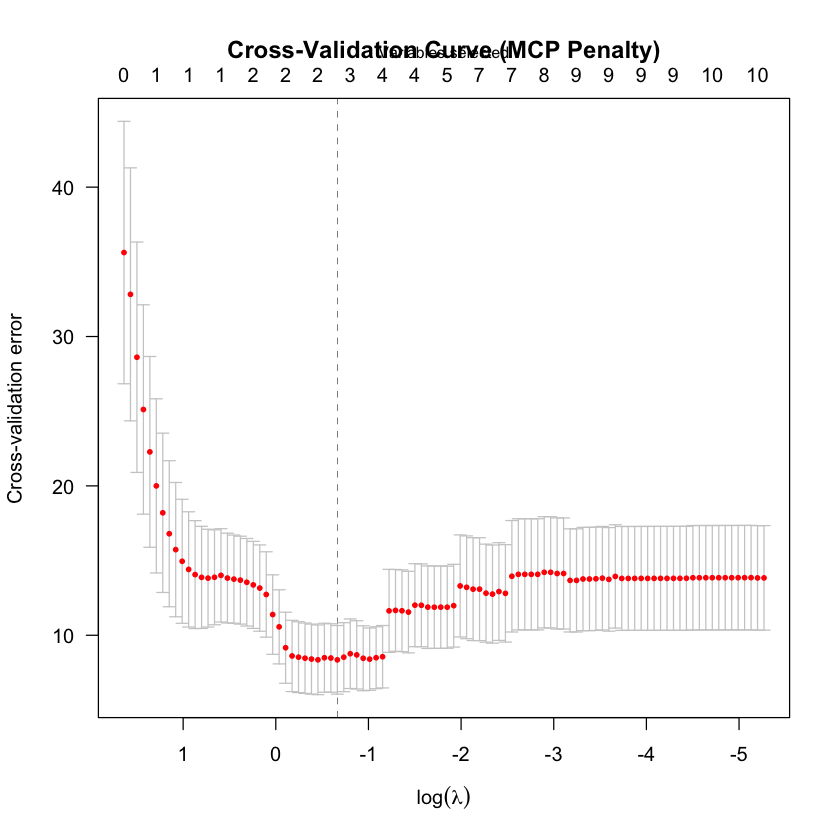

In [11]:
# Install the ncvreg package if you haven't already
# install.packages("ncvreg")
par(bg = "white")
# Load the ncvreg package
library(ncvreg)
library(dplyr) # For data manipulation if needed, though not strictly required here

# 1. Prepare the Data
# Use the mtcars dataset
data(mtcars)

# Define the response variable (y)
# Let's try to predict miles per gallon (mpg)
y <- mtcars$mpg

# Define the predictor variables (X)
# We'll use all other columns as predictors
# It's good practice to convert to a matrix for ncvreg
X <- as.matrix(mtcars %>% select(-mpg))

# Standardize predictors (ncvreg does this by default but good to be aware)
# X_scaled <- scale(X) # ncvreg handles this internally

# 2. Fit the Regularized Model using ncvreg
# We'll use the MCP penalty (default) for linear regression (family="gaussian")
# family="gaussian" is default for ncvreg, but explicitly stating it is clear
# penalty="MCP" is default, but explicitly stating it is clear

# The 'ncvreg' function computes the solution path for a range of lambda values
fit_mcp <- ncvreg(X, y, family="gaussian", penalty="MCP")

# 3. Explore the Results

# Print a summary of the fit object
# Shows coefficients at different lambda values
print(fit_mcp)

# Plot the regularization path
# This shows how coefficients change as lambda decreases (sparsity decreases)
plot(fit_mcp, main="Regularization Path (MCP Penalty)")

# Plot cross-validation error to choose the optimal lambda
# 'cv.ncvreg' performs cross-validation
cv_fit_mcp <- cv.ncvreg(X, y, family="gaussian", penalty="MCP")

# Plot the cross-validation curve
# Shows mean cross-validated error with standard error bars
# The top x-axis shows number of non-zero coefficients
# The bottom x-axis shows log(lambda)
plot(cv_fit_mcp, main="Cross-Validation Curve (MCP Penalty)")

# Identify the optimal lambda (lambda.min)
# This is the lambda value that gives the minimum cross-validated error
lambda_min <- cv_fit_mcp$lambda.min
cat("Optimal lambda (lambda.min):", lambda_min, "\n")

# Identify the lambda corresponding to 1 standard error from lambda.min (lambda.1se)
# This is often chosen for a more parsimonious model within 1 SE of the minimum
lambda_1se <- cv_fit_mcp$lambda.1se
cat("Lambda at 1 SE from min (lambda.1se):", lambda_1se, "\n")

# Get coefficients at the optimal lambda (lambda.min)
coef_min <- coef(fit_mcp, s=lambda_min)
cat("\nCoefficients at lambda.min:\n")
print(coef_min)

# Get coefficients at lambda.1se
coef_1se <- coef(fit_mcp, s=lambda_1se)
cat("\nCoefficients at lambda.1se:\n")
print(coef_1se)

# 4. Perform Inference (Get Standard Errors and Confidence Intervals)
# This is a key advantage of ncvreg for MCP/SCAD

# Use the 'summary' method on the cross-validation fit with the desired lambda
# We'll use lambda.min for demonstration
summary_lambda_min <- summary(cv_fit_mcp, lambda = lambda_min)
cat("\nSummary of selected model at lambda.min (with CIs and p-values):\n")
print(summary_lambda_min)

# # You can also get a summary for lambda.1se
# summary_lambda_1se <- summary(cv_fit_mcp, lambda = lambda_1se)
# cat("\nSummary of selected model at lambda.1se (with CIs and p-values):\n")
# print(summary_lambda_1se)

# You can directly extract confidence intervals from the summary object
# For lambda.min
conf_int_min <- summary_lambda_min$CI
cat("\nConfidence Intervals at lambda.min:\n")
print(conf_int_min)

# # For lambda.1se
# conf_int_1se <- summary_lambda_1se$CI
# cat("\nConfidence Intervals at lambda.1se:\n")
# print(conf_int_1se)

# 5. Prediction with the fitted model
# Create some new data for prediction (e.g., first 5 rows of X)
new_data <- X[1:5, ]
predictions_min <- predict(fit_mcp, X=new_data, s=lambda_min)
cat("\nPredictions for new data at lambda.min:\n")
print(predictions_min)

# Predict with the 'type="response"' for GLMs if applicable (e.g., logistic)
# For family="gaussian", "response" is the same as "link" (the linear predictor)

In [ ]:
library(dplyr)
simulate_data <- function(n, beta_true, sigma = 1) {
# Generate 10 independent covariates from N(0, 1)
X <- matrix(rnorm(n * 10), nrow = n, ncol = 10)
design <- cbind(Intercept = 1, X)
# Calculate Y based on the first four covariates and intercept
Y <- (design %*% beta_true) + rnorm(n, mean = 0, sd = sigma)
return(data.frame(Y = Y, X))
}
set.seed(123) # For reproducibility
sample_sizes <- c(50, 100, 150, 200, 500, 1000, 5000)
beta_true <- c(10, 0.25, 0.25, 0.1, 0.1, 0, 0, 0, 0, 0, 0)
names(beta_true) <- c(
"(Intercept)", paste0("X", 1:10)
)
data_list <- lapply(sample_sizes, function(n) {
replicate(100, simulate_data(n, beta_true), simplify = FALSE)
})


Attache Paket: 'dplyr'


Die folgenden Objekte sind maskiert von 'package:stats':

    filter, lag


Die folgenden Objekte sind maskiert von 'package:base':

    intersect, setdiff, setequal, union




In [ ]:
library(MASS)
eval_simulation <- function(sim_dta, beta_true) {
lm_full <- lm(Y ~
., data = sim_dta)
stepAIC_run <- stepAIC(lm_full, trace = FALSE)

# Extract coefficients and confidence intervals
coef_run <- coef(stepAIC_run)
conf_int <- confint(stepAIC_run)
# Bind true beta to coefficients
conf_df <- as.data.frame(conf_int) |>
mutate(beta_true = beta_true[names(coef_run)],
coefficient = row.names(conf_int))
conf_df |>
mutate(in_confint = between(beta_true, `2.5 %`, `97.5 %`)) |>
dplyr::select(coefficient, in_confint) |>
mutate(estimate = coef_run)
}


Attache Paket: 'MASS'


Das folgende Objekt ist maskiert 'package:dplyr':

    select




In [ ]:
# Evaluate for all data sets
start = Sys.time()
# Run evaluation for all data sets
results <- lapply(data_list, function(data) {
lapply(data, FUN = function(dataset) {
eval_simulation(dataset, beta_true = beta_true)
})
})
# Convert to tibble for summary
coverage <- bind_rows(
lapply(
results, function(df) bind_rows(df, .id = "replication")
),
.id = "sample_size"
) |>
mutate(
sample_size = as.integer(sample_size),
# switch sample size with the elements of sample_sizes
sample_size = sample_sizes[sample_size]
)
Sys.time() - start
## Time difference of 14.62565 secs

Time difference of 9.190073 secs

`summarise()` has grouped output by 'coefficient'. You can override using the
`.groups` argument.


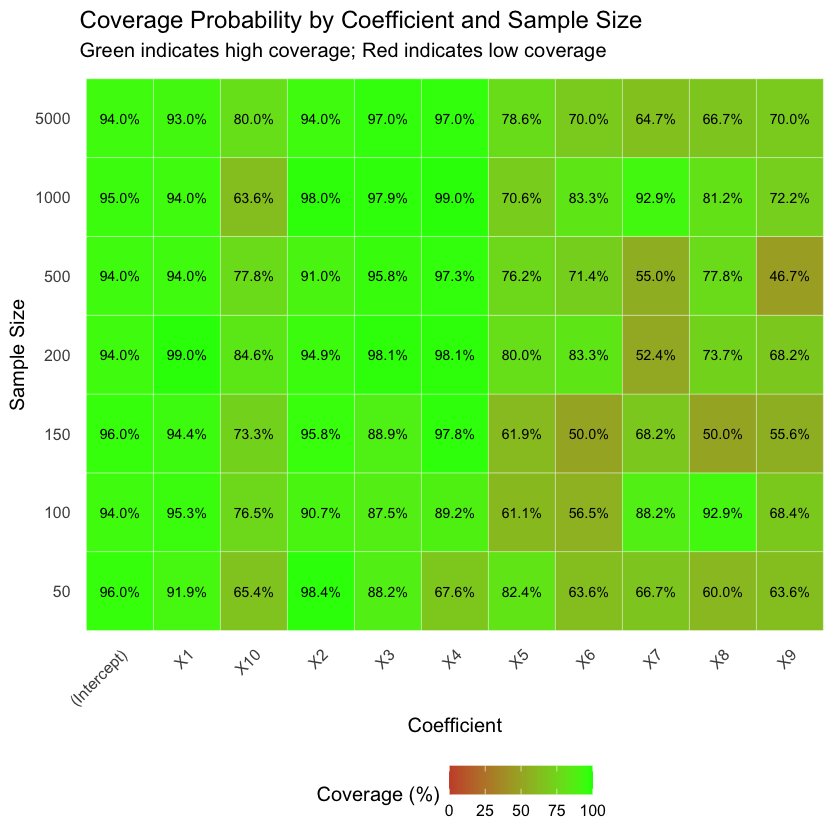

In [ ]:
# Check confidence intervals and calculate coverage probabilities per var
library(ggplot2)
coverage |>
group_by(coefficient, sample_size) |>
summarize(inconf_perc = 100 * mean(in_confint)) |>
ggplot(aes(x = coefficient, y = factor(sample_size), fill = inconf_perc)) +
geom_tile(color = "white") +
geom_text(aes(label = sprintf("%.1f%%", inconf_perc)), color = "black", size = 3) +
scale_fill_gradient(low = "#c95136", high = "green",
limits = c(0, 100), name = "Coverage (%)") +
labs(
x = "Coefficient",
y = "Sample Size",
title = "Coverage Probability by Coefficient and Sample Size",
subtitle = "Green indicates high coverage; Red indicates low coverage"
) +
theme_minimal(base_size = 12) +
theme(
axis.text.x = element_text(angle = 45, hjust = 1),
panel.grid = element_blank(),
legend.position = "bottom"
)

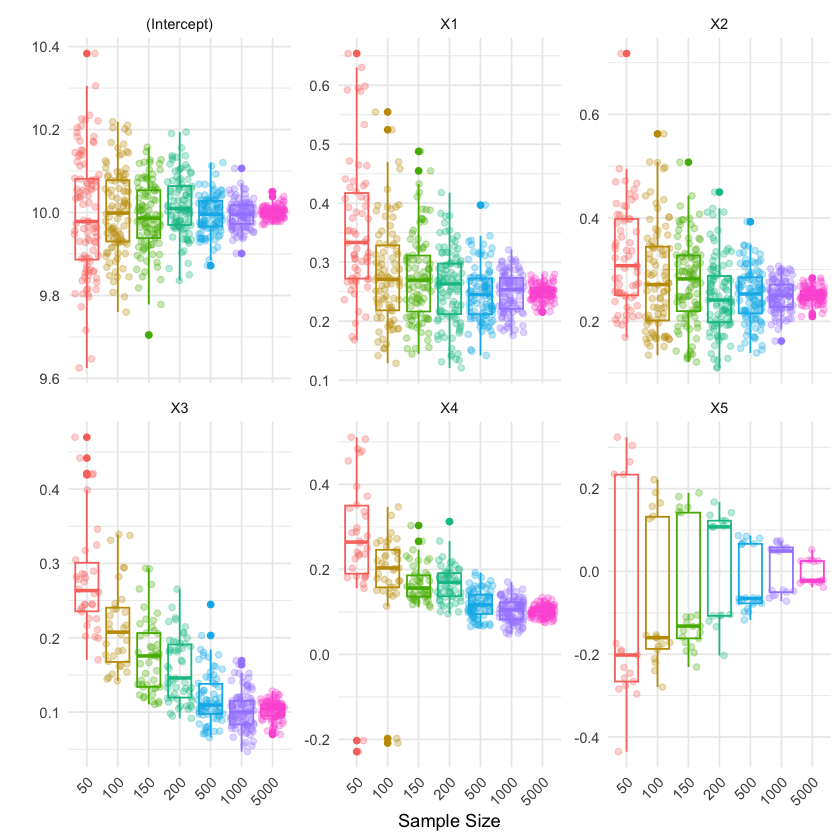

In [ ]:
ggplot(
coverage |>
filter(coefficient %in% names(beta_true)[1:6]),
aes(x = factor(sample_size), y = estimate, colour = factor(sample_size))
) +
geom_boxplot(fill = NA) +
geom_jitter(alpha = 0.3) +
facet_wrap(~coefficient, scales = "free_y", ncol = 3) +
labs(x = "Sample Size", y = "") +
theme_minimal() +
theme(
legend.position = "none",
axis.text.x = element_text(angle = 45, hjust = 1)
) 